In [1]:
import pandas as pd
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

path = "../data/raw/eph/usu_individual_T325.txt"

df = pd.read_csv(path, sep=";")
df.replace(" " * 12, None, inplace=True)
df

,CODUSU,"""ANO4""","""TRIMESTRE""","""NRO_HOGAR""","""COMPONENTE""","""H15""","""REGION""","""MAS_500""","""AGLOMERADO""","""PONDERA""",...,"""V21_03_M""","""V22_01_M""","""V22_02_M""","""V22_03_M""","""P_DECCF""","""P_RDECCF""","""P_GDECCF""","""P_PDECCF""","""P_IDECCF""","""P_ADECCF"""
0,TQRMNOTYPHKOKQCDEHNHB00867020,2025,3,1,8,0,42,"""S""",27,528,...,0,0,0,0,1,1,1,,1,1
1,TQRMNOTYPHKOKQCDEHNHB00867020,2025,3,1,9,0,42,"""S""",27,528,...,0,0,0,0,1,1,1,,1,1
2,TQRMNOTYPHKOKQCDEHNHB00867020,2025,3,1,1,1,42,"""S""",27,528,...,0,0,0,0,1,1,1,,1,1
3,TQRMNOTYPHKOKQCDEHNHB00867020,2025,3,1,2,1,42,"""S""",27,528,...,0,0,0,0,1,1,1,,1,1
4,TQRMNOTYPHKOKQCDEHNHB00867020,2025,3,1,3,1,42,"""S""",27,528,...,0,0,0,0,1,1,1,,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44941,TQRMNOPXUHJOLQCDEHLEH00862602,2025,3,2,5,0,40,"""N""",25,227,...,0,0,0,0,2,2,,2,2,2
44942,TQRMNOQPQHMKLQCDEHLEH00891262,2025,3,1,1,1,40,"""N""",25,336,...,0,0,0,0,7,9,,8,8,10
44943,TQRMNOQPQHMKLQCDEHLEH00891262,2025,3,1,2,1,40,"""N""",25,336,...,0,0,0,0,7,9,,8,8,10
44944,TQRMNOQPQHMKLQCDEHLEH00891262,2025,3,1,3,0,40,"""N""",25,336,...,0,0,0,0,7,9,,8,8,10


In [2]:
print(df.columns)
print(df.dtypes)
print(df.shape)

Index(['CODUSU                       ', ' "ANO4"', ' "TRIMESTRE"',
       ' "NRO_HOGAR"', ' "COMPONENTE"', ' "H15"', ' "REGION"', ' "MAS_500"',
       ' "AGLOMERADO"', ' "PONDERA"',
       ...
       ' "V21_03_M"', ' "V22_01_M"', ' "V22_02_M"', ' "V22_03_M"',
       ' "P_DECCF"', ' "P_RDECCF"', ' "P_GDECCF"', ' "P_PDECCF"',
       ' "P_IDECCF"', ' "P_ADECCF"'],
      dtype='object', length=235)
CODUSU                           object
 "ANO4"                           int64
 "TRIMESTRE"                      int64
 "NRO_HOGAR"                      int64
 "COMPONENTE"                     int64
                                  ...  
 "P_RDECCF"                      object
 "P_GDECCF"                      object
 "P_PDECCF"                      object
 "P_IDECCF"                      object
 "P_ADECCF"                      object
Length: 235, dtype: object
(44946, 235)


In [3]:
PP04B_COD = "PP04B_COD"
PP04D_COD = "PP04D_COD"
for col in df.columns:
	if PP04B_COD in col:
		PP04B_COD = col
		print(f"Found PP04B_COD column: {PP04B_COD}")
	if PP04D_COD in col:
		PP04D_COD = col
		print(f"Found PP04D_COD column: {PP04D_COD}")

Found PP04B_COD column:  "PP04B_COD"
Found PP04D_COD column:  "PP04D_COD"


In [4]:
df[PP04B_COD]

0                None
1                None
2                None
3                4000
4                None
             ...     
44941            None
44942            4000
44943            8600
44944            None
44945            4803
Name:  "PP04B_COD", Length: 44946, dtype: object

In [5]:
df_filtered = df.dropna(subset=[PP04B_COD, PP04D_COD]).copy()
print(df_filtered.shape)

(20066, 235)


PP04B Projection, and Modularity

Bipartite nodes: 656
Bipartite edges: 3279


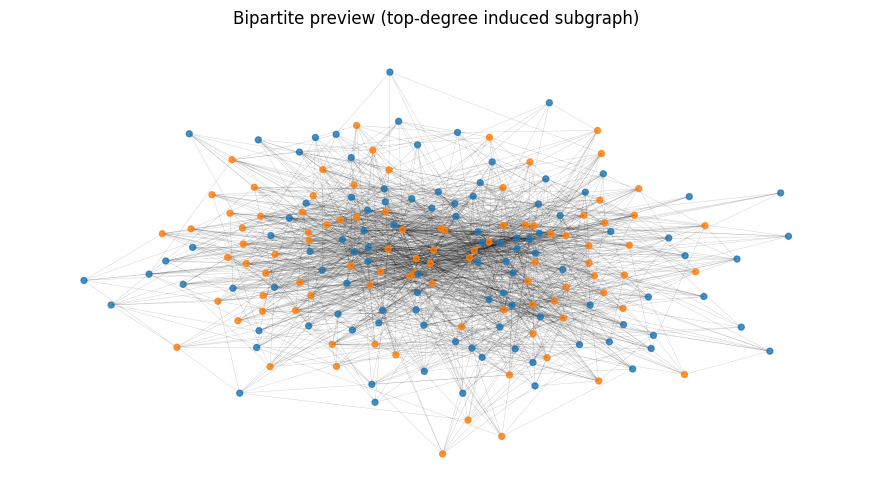

In [6]:
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

from scripts import gc, comm, pl

# Build a clean edge list from PP04B and PP04D
pairs = df_filtered[[PP04B_COD, PP04D_COD]].copy()
pairs.columns = ["pp04b", "pp04d"]
pairs["pp04b"] = pd.to_numeric(pairs["pp04b"], errors="coerce")
pairs["pp04d"] = pd.to_numeric(pairs["pp04d"], errors="coerce")
pairs = pairs.dropna().astype(int)

if pairs.empty:
	raise ValueError("No valid PP04B/PP04D pairs after numeric cleaning.")

# Disambiguate the second partition so node ids do not overlap
offset = int(pairs["pp04b"].max()) + 1
pairs["pp04d_disamb"] = pairs["pp04d"] + offset

B = gc.build_bipartite_graph(
	pairs,
	caes_id="pp04b",
	ciuo_id="pp04d_disamb",
	logscale=False,
	caes_partition=1,
	ciuo_partition=0,
)

print(f"Bipartite nodes: {B.number_of_nodes()}")
print(f"Bipartite edges: {B.number_of_edges()}")

# Quick visual: top-degree induced subgraph to keep the plot readable
top_n = 200
top_nodes = [n for n, _ in sorted(B.degree(), key=lambda x: x[1], reverse=True)[:top_n]]
B_view = B.subgraph(top_nodes).copy()

pos_b = nx.spring_layout(B_view, seed=45, iterations=1000)
node_colors = [
	"C0" if B_view.nodes[n].get("bipartite") == 1 else "C1" for n in B_view.nodes()
]

plt.figure(figsize=(11, 6))
nx.draw_networkx_nodes(B_view, pos_b, node_size=18, node_color=node_colors, alpha=0.8)
nx.draw_networkx_edges(B_view, pos_b, width=0.3, alpha=0.2)
plt.title("Bipartite preview (top-degree induced subgraph)")
plt.axis("off")
plt.show()

Projection nodes (alpha=0.05): 144
Projection edges (alpha=0.05): 843
Original graph had 143 nodes; largest component has 143 nodes.


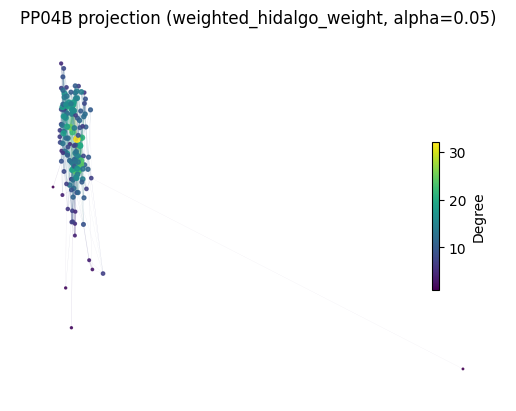

In [7]:
# PP04B projection with weighted Hidalgo weights
P_pp04b = gc.generic_weighted_projected_graph(
	B,
	target_partition=1,
	weight_function=gc.weighted_hidalgo_weight,
)

alpha = 0.05
P_pp04b_048 = gc.disparity_filter_backbone(P_pp04b, alpha=alpha)

print(f"Projection nodes (alpha={alpha}): {P_pp04b_048.number_of_nodes()}")
print(f"Projection edges (alpha={alpha}): {P_pp04b_048.number_of_edges()}")

if P_pp04b_048.number_of_nodes() == 0:
	raise ValueError("Projection is empty after filtering. Try a higher alpha.")

pos_048 = gc.get_projection_positions(P_pp04b_048, seed=45, method="energy")
degrees_048 = dict(P_pp04b_048.degree())

P_pp04b_048_aux = max(
	nx.connected_components(P_pp04b_048), key=len
)  # Largest connected component
pl.plot_projection_gradient(
	P_pp04b_048,
	pos=pos_048,
	node_values=degrees_048,
	title=f"PP04B projection (weighted_hidalgo_weight, alpha={alpha})",
	colorbar_label="Degree",
	cmap="viridis",
	save=False,
	node_size_map=degrees_048,
	factor_node_size=1.2,
	node_size_exponent=0.8,
	edge_alpha=0.15,
	node_alpha=0.85,
)

Best Louvain modularity: 0.5631
Best resolution: 1.0674
Detected communities: 8


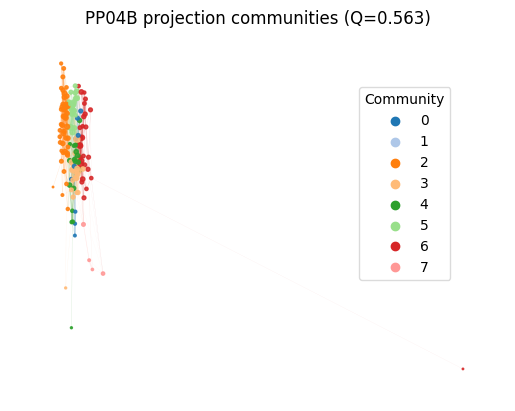

{8200: array([ 0.01003433, -0.00233133]),
 3600: array([-0.00891085, -0.00363573]),
 7701: array([-0.03169973,  0.00961445]),
 7702: array([-0.02378262, -0.00123561]),
 3100: array([-0.00101699,  0.01247943]),
 7200: array([ 0.00148391, -0.0110041 ]),
 35: array([-0.04139104,  0.00151448]),
 2601: array([-0.03860203,  0.01509657]),
 2602: array([-0.04214868,  0.00454633]),
 2603: array([-0.01210136,  0.00987509]),
 2604: array([-0.03226831,  0.0200175 ]),
 45: array([-0.00106396,  0.0024511 ]),
 48: array([0.00146527, 0.00097155]),
 49: array([-0.03902779,  0.00606483]),
 2100: array([-0.02691766,  0.00767132]),
 6200: array([ 0.01877319, -0.00187001]),
 56: array([-0.02166753, -0.01511034]),
 1600: array([-0.00776717,  0.01093954]),
 70: array([-0.03806358, -0.00057322]),
 73: array([-0.01237973, -0.04479233]),
 1100: array([-0.00954969,  0.00411024]),
 5201: array([-0.02979839,  0.0100165 ]),
 5202: array([0.01056245, 0.00069444]),
 84: array([-0.01042012, -0.00537725]),
 9301: array

In [8]:
# Louvain communities + modularity on the filtered PP04B projection
partition, modularity_score, best_resolution = comm.best_louvain_partition_random(
	P_pp04b_048,
	seed=45,
	n_samples=25,
	min_resolution=0.5,
	max_resolution=3.0,
)

print(f"Best Louvain modularity: {modularity_score:.4f}")
print(f"Best resolution: {best_resolution:.4f}")
print(f"Detected communities: {len(set(partition.values()))}")

community_ids = sorted(set(partition.values()))
cmap = plt.colormaps["tab20"]
group_color_map = {comm_id: cmap(i % 20) for i, comm_id in enumerate(community_ids)}

pl.plot_projection_by_group(
	P_pp04b_048,
	group_map=partition,
	group_color_map=group_color_map,
	title=f"PP04B projection communities (Q={modularity_score:.3f})",
	legend_title="Community",
	save=False,
	pos=pos_048,
	node_size_map=degrees_048,
	factor_node_size=1.2,
	node_size_exponent=0.8,
	edge_alpha=0.15,
	node_alpha=0.85,
)